In [1]:
import eyetracking_preprocessing
import glob
import mne
import pandas as pd
import numpy as np

In [2]:

subjects = subjects = [f"S{i:02}" for i in range(1, 2)]
S = 'S01'
top_dir =  '/Users/sm6511/Desktop/NIH_Experiment/Bids/'
#proj_path = "/misc/data12/sjapee/Sebastian-OrientationImagery/Data/"
#raw_dir = proj_path + '20240911/' + S + '/'
#logfile_dir = raw_dir + 'sheets/extracted_data'
bids_dir = top_dir + f'sub-{S}/ses-1/meg/sub-{S}_ses-1_task-OrientationImageryDynamic'
dsets = []
for i in range(1, 5, 1):
    ds = f'run-{i:02}'  
    pattern = f'{bids_dir}_{ds}_meg.ds'  
    matches = glob.glob(pattern)
    
    if matches:
        dsets.append(matches[0])
    else:
        print(f"No files found for pattern: {pattern}")

event_id = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
epoched_eyetrack = []
for i in range(len(dsets)):
    raw = mne.io.read_raw_ctf(dsets[i], preload=True, system_clock='ignore')
    info = mne.create_info(ch_names = ['x', 'y','pupil'], sfreq = 1200)
    eyes_preproc_meg = eyetracking_preprocessing.process_run(dsets[i])
    rawpreproc = mne.io.RawArray(eyes_preproc_meg.loc[:,['x_volts','y_volts','pupil']].to_numpy().T, info, first_samp=0, copy='auto', verbose=None)
    events = mne.events_from_annotations(raw)
    epochs = mne.Epochs(rawpreproc, events[0], event_id = event_id,tmin=-.2, tmax=3, baseline= None)
    epoched_eyetrack.append(epochs)
pattern = f'{bids_dir}*events.tsv'  # Find all event files in bids directory
matches = glob.glob(pattern)
matches.sort()
print(matches)
out = []
for event_files in matches:
    out.append(pd.read_csv(event_files,sep='\t'))
all_metadata = pd.concat(out).reset_index(drop=True)

all_metadata
epochs_stacked = mne.concatenate_epochs(epoched_eyetrack)
epochs_stacked.metadata = all_metadata
runs = [epoched_eyetrack[0], epoched_eyetrack[1], epoched_eyetrack[2], epoched_eyetrack[3]]  
run_lengths = [len(r) for r in runs]
run_nr = np.concatenate([[i] * l for i, l in enumerate(run_lengths)])
epochs_stacked.metadata['run_nr'] = run_nr
block_type = [k.split('/')[1] for k in epochs_stacked.metadata.trial_type]
condition = [k.split('/')[2] for k in epochs_stacked.metadata.trial_type]
epochs_stacked.metadata['block_type'] = block_type
epochs_stacked.metadata['condition'] = condition


ds directory : /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       3.71   71.61    0.00 mm <->    3.71   71.61    0.00 mm (orig :  -41.09   60.20 -249.13 mm) diff =    0.000 mm
      -3.71  -71.61    0.00 mm <->   -3.71  -71.61    0.00 mm (orig :   56.21  -45.16 -250.58 mm) diff =    0.000 mm
      89.99    0.00    0.00 mm <->   89.99    0.00    0.00 mm (orig :   69.07   70.39 -230.81 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    Measurement info composed.
Finding samples for /Users/sm6511/Desktop/NIH_Experiment/Bids/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-01_meg.ds/sub-S01_ses-1_task-OrientationImageryDynamic_run-01_meg.meg4: 
    Sy

/Users/sm6511/Desktop/Orientation-Imagery/AnalysisScripts/Eyetracking/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.00032981671392414384
removed 2737 samples
removed 668 samples
removed 9 samples
removed 2 samples
removed 2 samples
Creating RawArray with float64 data, n_channels=3, n_times=595520
    Range : 0 ... 595519 =      0.000 ...   496.266 secs
Ready.
Used Annotations descriptions: [np.str_('S01/Dynamic/0022_Left'), np.str_('S01/Dynamic/0022_Right'), np.str_('S01/Dynamic/0067_Left'), np.str_('S01/Dynamic/0067_Right'), np.str_('S01/Dynamic/0112_Left'), np.str_('S01/Dynamic/0112_Right'), np.str_('S01/Dynamic/0157_Left'), np.str_('S01/Dynamic/0157_Right'), np.str_('S01/Dynamic/0202_Left'), np.str_('S01/Dynamic/0202_Right'), np.str_('S01/Dynamic/0247_Left'), np.str_('S01/Dynamic/0247_Right'), np.str_('S01/Dynamic/0292_Left'), np.str_('S01/Dynamic/0292_Right'), np.str_('S01/Dynamic/0337_Left'), np.str_('S01/Dynamic/0337_Right'), np.str_('S01/Dynamic/catch')]
Not setting metadata
126 matching events found
No baseline correction applied
0 projection items activated
ds directory : /User

/Users/sm6511/Desktop/Orientation-Imagery/AnalysisScripts/Eyetracking/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.0003732461482373357
removed 7282 samples
removed 1062 samples
removed 168 samples
removed 112 samples
removed 79 samples
Creating RawArray with float64 data, n_channels=3, n_times=566480
    Range : 0 ... 566479 =      0.000 ...   472.066 secs
Ready.
Used Annotations descriptions: [np.str_('S01/Dynamic/0022_Left'), np.str_('S01/Dynamic/0022_Right'), np.str_('S01/Dynamic/0067_Left'), np.str_('S01/Dynamic/0067_Right'), np.str_('S01/Dynamic/0112_Left'), np.str_('S01/Dynamic/0112_Right'), np.str_('S01/Dynamic/0157_Left'), np.str_('S01/Dynamic/0157_Right'), np.str_('S01/Dynamic/0202_Left'), np.str_('S01/Dynamic/0202_Right'), np.str_('S01/Dynamic/0247_Left'), np.str_('S01/Dynamic/0247_Right'), np.str_('S01/Dynamic/0292_Left'), np.str_('S01/Dynamic/0292_Right'), np.str_('S01/Dynamic/0337_Left'), np.str_('S01/Dynamic/0337_Right'), np.str_('S01/Dynamic/catch')]
Not setting metadata
126 matching events found
No baseline correction applied
0 projection items activated
ds directory : 

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


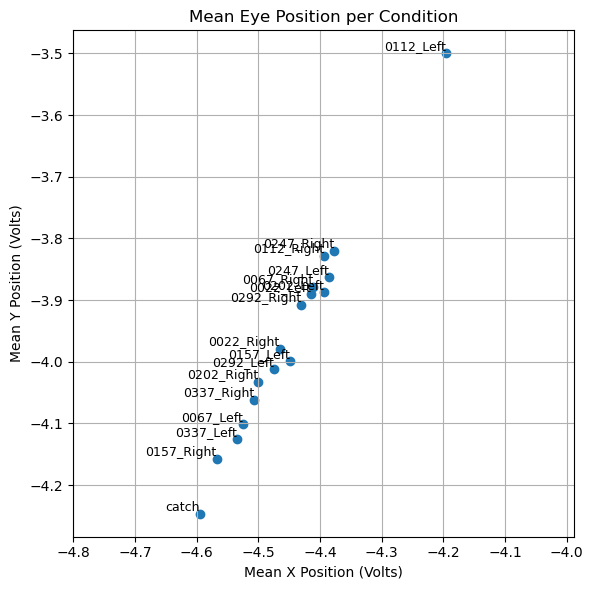

In [9]:
import matplotlib.pyplot as plt

eye_data = epochs_stacked.copy().pick_channels(['x', 'y']).get_data()  # shape: (n_epochs, 2, n_times)
metadata = epochs_stacked.metadata
condition_col = 'condition'
unique_conditions = metadata[condition_col].unique()

# Initialize lists to hold mean x and y positions
mean_xs = []
mean_ys = []
labels = []

for cond in unique_conditions:
    idx = metadata[condition_col] == cond
    # Take mean over epochs and time (axis=(0, 2))
    mean_x = eye_data[idx, 0, :].mean(axis=(0, 1))  # x-channel
    mean_y = eye_data[idx, 1, :].mean(axis=(0, 1))  # y-channel
    mean_xs.append(mean_x)
    mean_ys.append(mean_y)
    labels.append(cond)

# Plot scatter
plt.figure(figsize=(6, 6))
plt.scatter(mean_xs, mean_ys)

# Annotate each point with its condition label
for x, y, label in zip(mean_xs, mean_ys, labels):
    plt.text(x, y, label, fontsize=9, ha='right', va='bottom')

plt.xlabel('Mean X Position (Volts)')
plt.ylabel('Mean Y Position (Volts)')
plt.title('Mean Eye Position per Condition')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


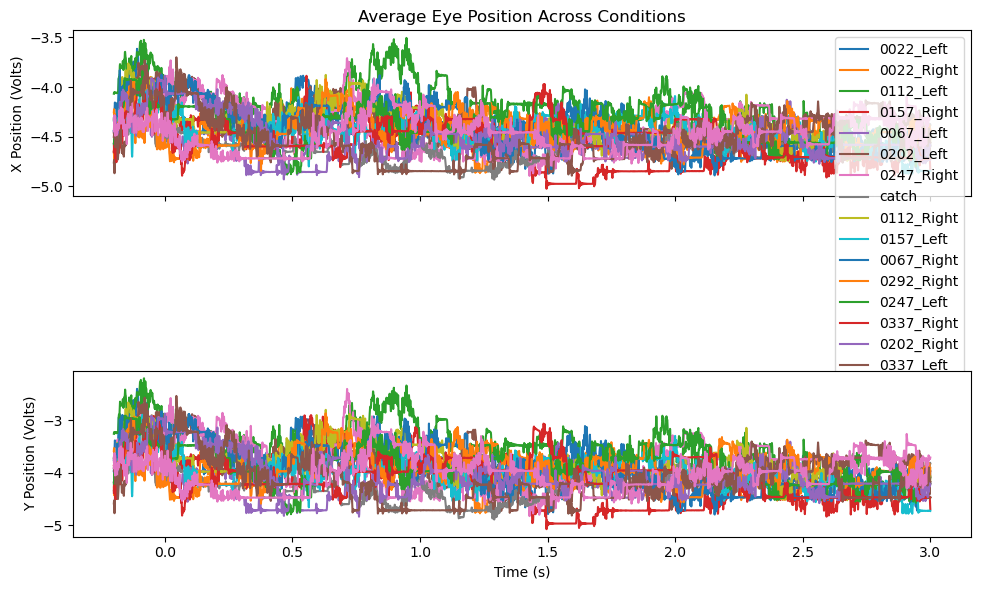

In [99]:
eye_data = epochs_stacked.copy().pick_channels(['x', 'y']).get_data()  # shape: (n_epochs, 2, n_times)
metadata = epochs_stacked.metadata
condition_col = 'condition' 
unique_conditions = metadata[condition_col].unique()

import matplotlib.pyplot as plt

times = epochs_stacked.times
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for cond in unique_conditions:
    idx = metadata[condition_col] == cond
    mean_x = eye_data[idx, 0, :].mean(axis=0)  # x-channel
    mean_y = eye_data[idx, 1, :].mean(axis=0)  # y-channel
    
    axs[0].plot(times, mean_x, label=cond)
    axs[1].plot(times, mean_y, label=cond)

axs[0].set_ylabel('X Position (Volts)')
axs[1].set_ylabel('Y Position (Volts)')
axs[1].set_xlabel('Time (s)')
axs[0].legend()
axs[0].set_title('Average Eye Position Across Conditions')
plt.tight_layout()
plt.show()


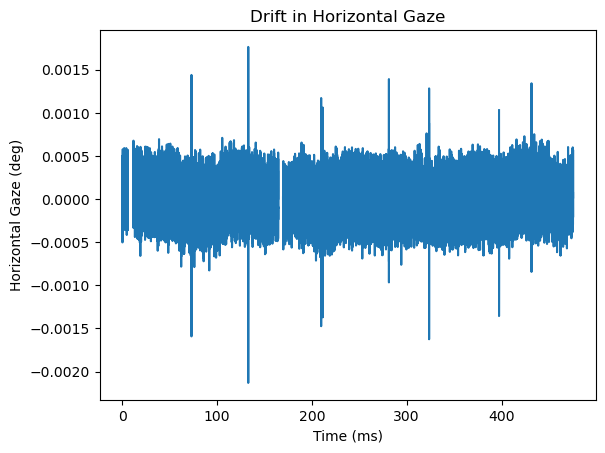

In [100]:
import matplotlib.pyplot as plt
plt.plot(eyes_preproc_meg['time'], eyes_preproc_meg['x_deg'])
plt.xlabel('Time (ms)')
plt.ylabel('Horizontal Gaze (deg)')
plt.title('Drift in Horizontal Gaze')
plt.show()

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import mne
import glob

subjects = [f"S{i:02}" for i in range(1, 21)]
bids_top_dir = '/System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/'
event_id = list(range(1, 18))  # 17 conditions

# Store all data for plotting
all_xs = []
all_ys = []
all_conditions = []
all_subjects = []

for S in subjects:
    print(f"Processing {S}")
    bids_dir = f'{bids_top_dir}bids_dir/sub-{S}/ses-1/meg/sub-{S}_ses-1_task-OrientationImageryDynamic'
    
    # Load .ds files
    dsets = []
    for i in range(1, 5):
        ds = f'run-{i:02}'
        pattern = f'{bids_dir}_{ds}_meg.ds'
        matches = glob.glob(pattern)
        if matches:
            dsets.append(matches[0])
        else:
            print(f"No files found for pattern: {pattern}")
    
    # Preprocess and epoch
    epoched_eyetrack = []
    for path in dsets:
        raw = mne.io.read_raw_ctf(path, preload=True, system_clock='ignore')
        info = mne.create_info(['x', 'y', 'pupil'], sfreq=1200)
        eyes = eyetracking_preprocessing.process_run(path)
        raw_eye = mne.io.RawArray(eyes[['x_volts', 'y_volts', 'pupil']].to_numpy().T, info)
        events, _ = mne.events_from_annotations(raw)
        epochs = mne.Epochs(raw_eye, events, event_id=event_id, tmin=-.2, tmax=3.0, baseline=None)
        epoched_eyetrack.append(epochs)

    # Combine metadata
    pattern = f'{bids_dir}*events.tsv'
    matches = glob.glob(pattern)
    matches.sort()
    meta_list = [pd.read_csv(f, sep='\t') for f in matches]
    all_metadata = pd.concat(meta_list).reset_index(drop=True)
    
    epochs_stacked = mne.concatenate_epochs(epoched_eyetrack)
    epochs_stacked.metadata = all_metadata
    run_lengths = [len(r) for r in epoched_eyetrack]
    run_nr = np.concatenate([[i] * l for i, l in enumerate(run_lengths)])
    epochs_stacked.metadata['run_nr'] = run_nr

    block_type = [k.split('/')[1] for k in epochs_stacked.metadata.trial_type]
    condition = [k.split('/')[2] for k in epochs_stacked.metadata.trial_type]
    epochs_stacked.metadata['block_type'] = block_type
    epochs_stacked.metadata['condition'] = condition

    # Get mean positions
    eye_data = epochs_stacked.copy().pick_channels(['x', 'y']).get_data()
    metadata = epochs_stacked.metadata
    condition_col = 'condition'
    unique_conditions = metadata[condition_col].unique()

    for cond in unique_conditions:
        idx = metadata[condition_col] == cond
        mean_x = eye_data[idx, 0, :].mean(axis=(0, 1))
        mean_y = eye_data[idx, 1, :].mean(axis=(0, 1))
        all_xs.append(mean_x)
        all_ys.append(mean_y)
        all_conditions.append(cond)
        all_subjects.append(S)


Processing S01
ds directory : /System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/bids_dir/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-01_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
       3.71   71.61    0.00 mm <->    3.71   71.61   -0.00 mm (orig :  -41.09   60.20 -249.13 mm) diff =    0.000 mm
      -3.71  -71.61    0.00 mm <->   -3.71  -71.61   -0.00 mm (orig :   56.21  -45.16 -250.58 mm) diff =    0.000 mm
      89.99    0.00    0.00 mm <->   89.99    0.00    0.00 mm (orig :   69.07   70.39 -230.81 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    Measurement info composed.
Finding samples for /System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/bids_dir/sub-S01/ses-1/meg/sub-S01_ses-1_task-Or

/System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/!Most Important:Final Scripts for Experiment/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.00032981671392414384
removed 2737 samples
removed 668 samples
removed 9 samples
removed 2 samples
removed 2 samples
Creating RawArray with float64 data, n_channels=3, n_times=595520
    Range : 0 ... 595519 =      0.000 ...   496.266 secs
Ready.
Used Annotations descriptions: ['S01/Dynamic/0022_Left', 'S01/Dynamic/0022_Right', 'S01/Dynamic/0067_Left', 'S01/Dynamic/0067_Right', 'S01/Dynamic/0112_Left', 'S01/Dynamic/0112_Right', 'S01/Dynamic/0157_Left', 'S01/Dynamic/0157_Right', 'S01/Dynamic/0202_Left', 'S01/Dynamic/0202_Right', 'S01/Dynamic/0247_Left', 'S01/Dynamic/0247_Right', 'S01/Dynamic/0292_Left', 'S01/Dynamic/0292_Right', 'S01/Dynamic/0337_Left', 'S01/Dynamic/0337_Right', 'S01/Dynamic/catch']
Not setting metadata
126 matching events found
No baseline correction applied
0 projection items activated
ds directory : /System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/bids_dir/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_run-02_

/System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/!Most Important:Final Scripts for Experiment/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.0003732461482373357
removed 7282 samples
removed 1062 samples
removed 168 samples
removed 112 samples
removed 79 samples
Creating RawArray with float64 data, n_channels=3, n_times=566480
    Range : 0 ... 566479 =      0.000 ...   472.066 secs
Ready.
Used Annotations descriptions: ['S01/Dynamic/0022_Left', 'S01/Dynamic/0022_Right', 'S01/Dynamic/0067_Left', 'S01/Dynamic/0067_Right', 'S01/Dynamic/0112_Left', 'S01/Dynamic/0112_Right', 'S01/Dynamic/0157_Left', 'S01/Dynamic/0157_Right', 'S01/Dynamic/0202_Left', 'S01/Dynamic/0202_Right', 'S01/Dynamic/0247_Left', 'S01/Dynamic/0247_Right', 'S01/Dynamic/0292_Left', 'S01/Dynamic/0292_Right', 'S01/Dynamic/0337_Left', 'S01/Dynamic/0337_Right', 'S01/Dynamic/catch']
Not setting metadata
126 matching events found
No baseline correction applied
0 projection items activated
ds directory : /System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/bids_dir/sub-S01/ses-1/meg/sub-S01_ses-1_task-OrientationImageryDynamic_ru

...

threshold: 0.02822527382672086
removed 1563 samples
removed 74 samples
removed 2525 samples
removed 1734 samples
removed 1953 samples
removed 1340 samples
Creating RawArray with float64 data, n_channels=3, n_times=584080
    Range : 0 ... 584079 =      0.000 ...   486.733 secs
Ready.
Used Annotations descriptions: ['S01/Dynamic/0022_Left', 'S01/Dynamic/0022_Right', 'S01/Dynamic/0067_Left', 'S01/Dynamic/0067_Right', 'S01/Dynamic/0112_Left', 'S01/Dynamic/0112_Right', 'S01/Dynamic/0157_Left', 'S01/Dynamic/0157_Right', 'S01/Dynamic/0202_Left', 'S01/Dynamic/0202_Right', 'S01/Dynamic/0247_Left', 'S01/Dynamic/0247_Right', 'S01/Dynamic/0292_Left', 'S01/Dynamic/0292_Right', 'S01/Dynamic/0337_Left', 'S01/Dynamic/0337_Right', 'S01/Dynamic/catch']
Not setting metadata
123 matching events found
No baseline correction applied
0 projection items activated
ds directory : /System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/bids_dir/sub-S14/ses-1/meg/sub-S14_ses-1_task-Orienta

/System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/!Most Important:Final Scripts for Experiment/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.040269367397410896
removed 17072 samples
removed 284 samples
removed 493 samples
removed 586 samples
removed 679 samples
removed 538 samples
Creating RawArray with float64 data, n_channels=3, n_times=569200
    Range : 0 ... 569199 =      0.000 ...   474.332 secs
Ready.
Used Annotations descriptions: ['S01/Dynamic/0022_Left', 'S01/Dynamic/0022_Right', 'S01/Dynamic/0067_Left', 'S01/Dynamic/0067_Right', 'S01/Dynamic/0112_Left', 'S01/Dynamic/0112_Right', 'S01/Dynamic/0157_Left', 'S01/Dynamic/0157_Right', 'S01/Dynamic/0202_Left', 'S01/Dynamic/0202_Right', 'S01/Dynamic/0247_Left', 'S01/Dynamic/0247_Right', 'S01/Dynamic/0292_Left', 'S01/Dynamic/0292_Right', 'S01/Dynamic/0337_Left', 'S01/Dynamic/0337_Right', 'S01/Dynamic/catch']
Not setting metadata
123 matching events found
No baseline correction applied
0 projection items activated
ds directory : /System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/bids_dir/sub-S16/ses-1/meg/sub-S16_ses-1_task-Orientat

/System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/!Most Important:Final Scripts for Experiment/eyetracking_preprocessing.py:141: RuntimeWarning: All-NaN slice encountered
  max_dilation_speed[is_valid]                = np.nanmax(np.abs(back_fwd_dilation),axis=0)


threshold: 0.05721297674149542
removed 20248 samples
removed 881 samples
removed 3255 samples
removed 2621 samples
removed 2578 samples
removed 2398 samples
Creating RawArray with float64 data, n_channels=3, n_times=571320
    Range : 0 ... 571319 =      0.000 ...   476.099 secs
Ready.
Used Annotations descriptions: ['S01/Dynamic/0022_Left', 'S01/Dynamic/0022_Right', 'S01/Dynamic/0067_Left', 'S01/Dynamic/0067_Right', 'S01/Dynamic/0112_Left', 'S01/Dynamic/0112_Right', 'S01/Dynamic/0157_Left', 'S01/Dynamic/0157_Right', 'S01/Dynamic/0202_Left', 'S01/Dynamic/0202_Right', 'S01/Dynamic/0247_Left', 'S01/Dynamic/0247_Right', 'S01/Dynamic/0292_Left', 'S01/Dynamic/0292_Right', 'S01/Dynamic/0337_Left', 'S01/Dynamic/0337_Right', 'S01/Dynamic/catch']
Not setting metadata
123 matching events found
No baseline correction applied
0 projection items activated
ds directory : /System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/Data/Bids/bids_dir/sub-S19/ses-1/meg/sub-S19_ses-1_task-Orien

/var/folders/9m/6b08zp213znc3k12g6gpjj9rqx2ly9/T/ipykernel_28170/1940382213.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = {cond: cm.get_cmap('tab20')(i / len(unique_conds)) for i, cond in enumerate(unique_conds)}


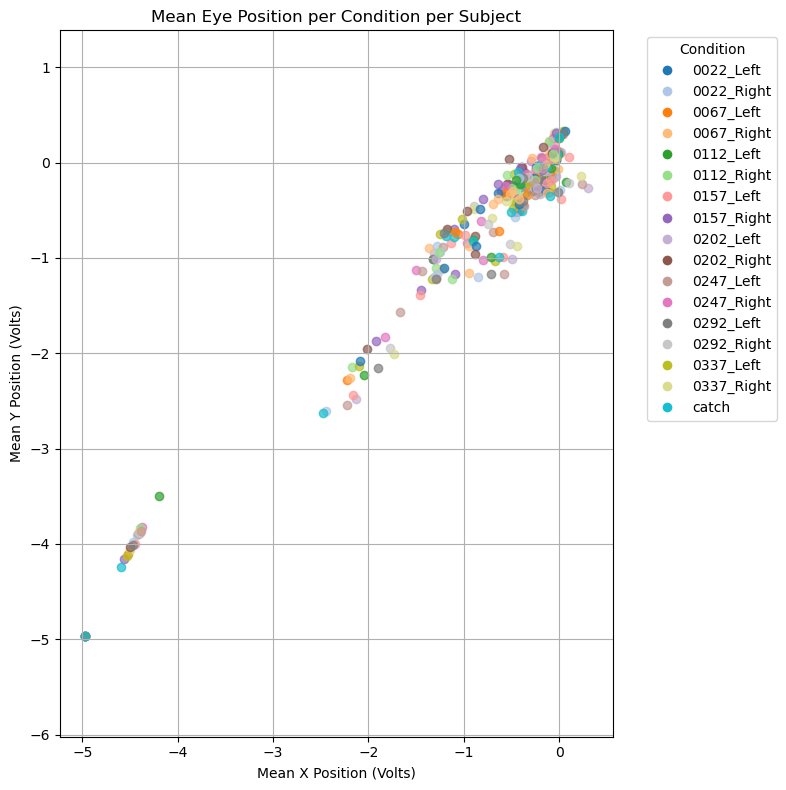

In [11]:
# --- Plotting ---
plt.figure(figsize=(8, 8))

# Assign color to each condition
unique_conds = sorted(set(all_conditions))
color_map = {cond: cm.get_cmap('tab20')(i / len(unique_conds)) for i, cond in enumerate(unique_conds)}

for x, y, cond, subj in zip(all_xs, all_ys, all_conditions, all_subjects):
    plt.scatter(x, y, color=color_map[cond], label=cond if subj == subjects[0] else "", alpha=0.7)

# One legend entry per condition
handles = [plt.Line2D([0], [0], marker='o', color='w', label=cond,
                      markerfacecolor=color_map[cond], markersize=8) for cond in unique_conds]
plt.legend(handles=handles, title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Mean X Position (Volts)')
plt.ylabel('Mean Y Position (Volts)')
plt.title('Mean Eye Position per Condition per Subject')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

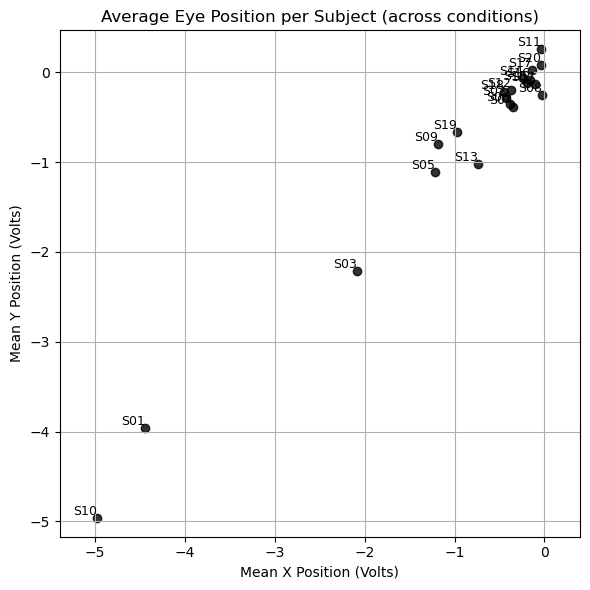

In [12]:
# --- Second Plot: One dot per subject (averaged across conditions) ---
plt.figure(figsize=(6, 6))

# Create a DataFrame for easier manipulation
df = pd.DataFrame({
    'x': all_xs,
    'y': all_ys,
    'condition': all_conditions,
    'subject': all_subjects
})

# Compute mean x and y per subject
df_avg = df.groupby('subject')[['x', 'y']].mean().reset_index()

# Plot one dot per subject
plt.scatter(df_avg['x'], df_avg['y'], color='black', alpha=0.8)

for _, row in df_avg.iterrows():
    plt.text(row['x'], row['y'], row['subject'], fontsize=9, ha='right', va='bottom')

plt.xlabel('Mean X Position (Volts)')
plt.ylabel('Mean Y Position (Volts)')
plt.title('Average Eye Position per Subject (across conditions)')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()


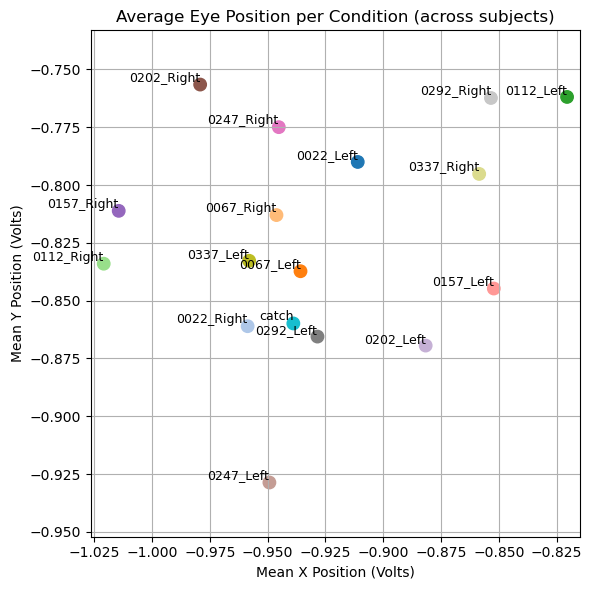

In [13]:
# --- Second Plot: One dot per condition (averaged across subjects) ---
plt.figure(figsize=(6, 6))

# Create a DataFrame from your data
df = pd.DataFrame({
    'x': all_xs,
    'y': all_ys,
    'condition': all_conditions,
    'subject': all_subjects
})

# Compute mean x and y per condition
df_avg = df.groupby('condition')[['x', 'y']].mean().reset_index()

# Re-use the color map from earlier
df_avg['color'] = df_avg['condition'].map(color_map)

# Plot one dot per condition
plt.scatter(df_avg['x'], df_avg['y'], color=df_avg['color'], s=80)

# Annotate each point with the condition name
for _, row in df_avg.iterrows():
    plt.text(row['x'], row['y'], row['condition'], fontsize=9, ha='right', va='bottom')

plt.xlabel('Mean X Position (Volts)')
plt.ylabel('Mean Y Position (Volts)')
plt.title('Average Eye Position per Condition (across subjects)')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()
